# Title: Superstore Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df=pd.read_excel(r"C:\Users\data\Downloads\Superstore 2014.xlsx")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656
1,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.900,5,0.0,34.4700
2,172,CA-2014-118962,2014-08-05,2014-08-09,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,90004,West,OFF-PA-10000659,Office Supplies,Paper,"Adams Phone Message Book, Professional, 400 Me...",20.940,3,0.0,9.8418
3,173,CA-2014-118962,2014-08-05,2014-08-09,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,90004,West,OFF-PA-10001144,Office Supplies,Paper,Xerox 1913,110.960,2,0.0,53.2608
4,1143,CA-2014-146969,2014-09-29,2014-10-03,Standard Class,AP-10915,Arthur Prichep,Consumer,United States,Los Angeles,...,90045,West,OFF-FA-10001561,Office Supplies,Fasteners,Stockwell Push Pins,8.720,4,0.0,2.8776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1988,9630,CA-2014-118192,2014-01-13,2014-01-18,Standard Class,MM-17920,Michael Moore,Consumer,United States,Newark,...,43055,East,OFF-BI-10003476,Office Supplies,Binders,Avery Metallic Poly Binders,3.438,2,0.7,-2.5212
1989,9712,CA-2014-114251,2014-11-05,2014-11-10,Standard Class,MD-17350,Maribeth Dona,Consumer,United States,Philadelphia,...,19143,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,13.194,2,0.7,-8.7960
1990,9870,CA-2014-114195,2014-11-01,2014-11-03,First Class,EA-14035,Erin Ashbrook,Corporate,United States,Mason,...,45040,East,OFF-BI-10000494,Office Supplies,Binders,Acco Economy Flexible Poly Round Ring Binder,3.132,2,0.7,-2.6100
1991,9871,CA-2014-114195,2014-11-01,2014-11-03,First Class,EA-14035,Erin Ashbrook,Corporate,United States,Mason,...,45040,East,OFF-BI-10001658,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,22.428,3,0.7,-17.9424


# Data Cleaning

In [19]:
# Checking for duplicates

df[df.duplicated(keep=False)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [15]:
# Checking concise summary of the dataset for null values and correct datatypes

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         1993 non-null   int64         
 1   Order ID       1993 non-null   object        
 2   Order Date     1993 non-null   datetime64[ns]
 3   Ship Date      1993 non-null   datetime64[ns]
 4   Ship Mode      1993 non-null   object        
 5   Customer ID    1993 non-null   object        
 6   Customer Name  1993 non-null   object        
 7   Segment        1993 non-null   object        
 8   Country        1993 non-null   object        
 9   City           1993 non-null   object        
 10  State          1993 non-null   object        
 11  Postal Code    1993 non-null   int64         
 12  Region         1993 non-null   object        
 13  Product ID     1993 non-null   object        
 14  Category       1993 non-null   object        
 15  Sub-Category   1993 n

In [21]:
# Datatype conversion

df['Row ID']=df['Row ID'].astype(object)
df['Row ID'].dtypes

dtype('O')

In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         1993 non-null   object        
 1   Order ID       1993 non-null   object        
 2   Order Date     1993 non-null   datetime64[ns]
 3   Ship Date      1993 non-null   datetime64[ns]
 4   Ship Mode      1993 non-null   object        
 5   Customer ID    1993 non-null   object        
 6   Customer Name  1993 non-null   object        
 7   Segment        1993 non-null   object        
 8   Country        1993 non-null   object        
 9   City           1993 non-null   object        
 10  State          1993 non-null   object        
 11  Postal Code    1993 non-null   int64         
 12  Region         1993 non-null   object        
 13  Product ID     1993 non-null   object        
 14  Category       1993 non-null   object        
 15  Sub-Category   1993 n

# Exploration

## Analyzing Sales Performance

In [110]:
#Calculate Total Sales and Total Quantity Sold.

total_sales = np.sum(df['Sales'])  # Total Sales

print(f'Total Sales: {total_sales}')

Total Sales: 484247.49809999997


In [112]:
total_quantity = np.sum(df['Quantity'])     # Total Quantity

print(f'Total Quantity: {total_quantity}')

Total Quantity: 7581


In [57]:
# Identify the Top 5 Best-Selling Products by Total Sales.

df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)

Product Name
Cisco TelePresence System EX90 Videoconferencing Unit        22638.480
Lexmark MX611dhe Monochrome Laser Printer                    11219.934
HP Designjet T520 Inkjet Large Format Printer - 24" Color     9624.945
Ibico EPK-21 Electric Binding System                          9449.950
High Speed Automatic Electric Letter Opener                   8187.650
Name: Sales, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

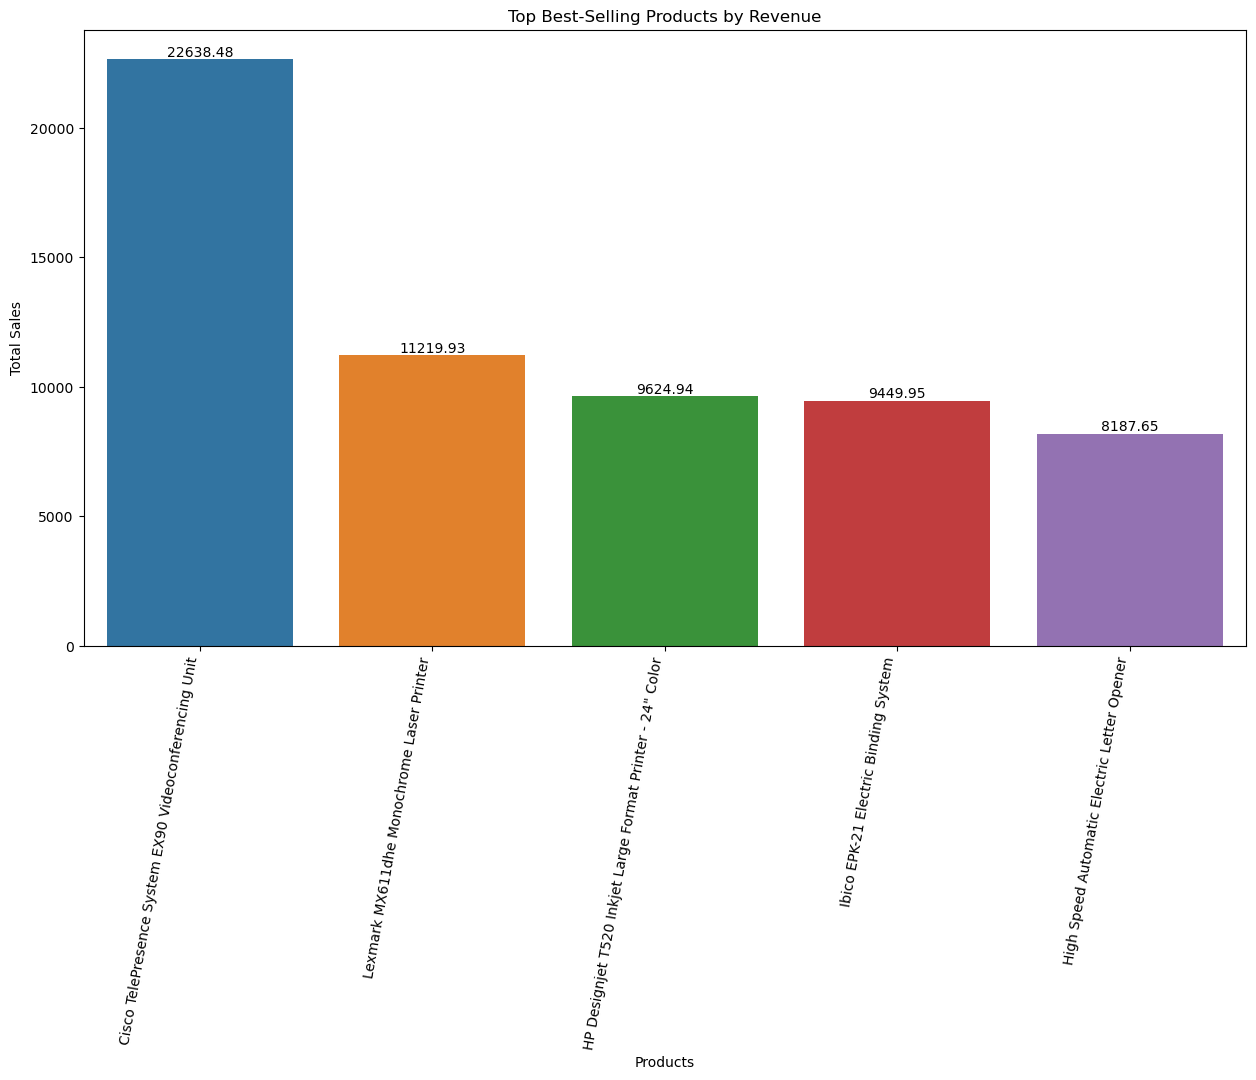

In [87]:
# Viz

import warnings
warnings.filterwarnings('ignore')

products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(15, 8))

plot = sns.barplot(data=products, palette=sns.color_palette('tab10'))
for bars in plot.containers:
    plot.bar_label(bars, [f'{x:.2f}' for x in bars.datavalues])
plot.set_xlabel('Products')
plot.set_ylabel('Total Sales')   
plt.title('Top Best-Selling Products by Revenue')
plt.xticks(rotation=80, ha='right')
plt.show

In [1]:
# Determine the Region with the Highest Revenue.

df.groupby('Region')['Sales'].sum().round(2).sort_values(ascending=False)

NameError: name 'df' is not defined

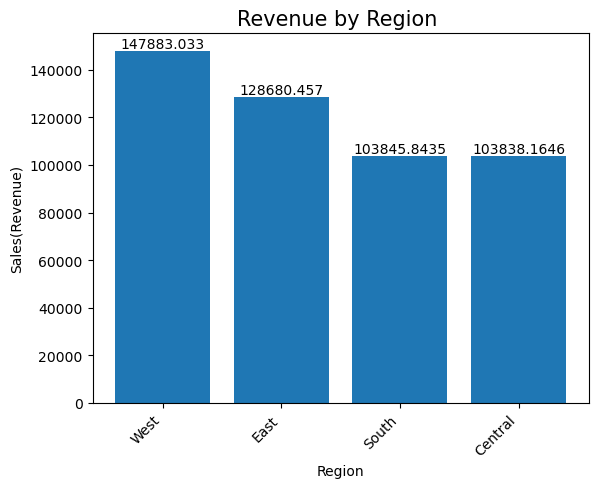

In [114]:
# Viz

region =df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.bar(region.index, region.values)
for i, value in enumerate(region.values):
    plt.text(i, value, f'{value}', ha='center', va='bottom')
    
plt.xlabel('Region')
plt.ylabel('Sales(Revenue)')
plt.title('Revenue by Region ', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.show()

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1993 entries, 0 to 1992
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         1993 non-null   object        
 1   Order ID       1993 non-null   object        
 2   Order Date     1993 non-null   datetime64[ns]
 3   Ship Date      1993 non-null   datetime64[ns]
 4   Ship Mode      1993 non-null   object        
 5   Customer ID    1993 non-null   object        
 6   Customer Name  1993 non-null   object        
 7   Segment        1993 non-null   object        
 8   Country        1993 non-null   object        
 9   City           1993 non-null   object        
 10  State          1993 non-null   object        
 11  Postal Code    1993 non-null   int64         
 12  Region         1993 non-null   object        
 13  Product ID     1993 non-null   object        
 14  Category       1993 non-null   object        
 15  Sub-Category   1993 n

In [67]:
# Analyze monthly sales trends — which months have the highest and lowest sales?

df['Month'] = df['Order Date'].dt.strftime('%b')  # Extract month as abbreviated name, adding new month column
df['Year'] = df['Order Date'].dt.year  # Extract year and add to new columns
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month,Year
0,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656,Jun,2014
1,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.900,5,0.0,34.4700,Jun,2014
2,172,CA-2014-118962,2014-08-05,2014-08-09,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,OFF-PA-10000659,Office Supplies,Paper,"Adams Phone Message Book, Professional, 400 Me...",20.940,3,0.0,9.8418,Aug,2014
3,173,CA-2014-118962,2014-08-05,2014-08-09,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,OFF-PA-10001144,Office Supplies,Paper,Xerox 1913,110.960,2,0.0,53.2608,Aug,2014
4,1143,CA-2014-146969,2014-09-29,2014-10-03,Standard Class,AP-10915,Arthur Prichep,Consumer,United States,Los Angeles,...,OFF-FA-10001561,Office Supplies,Fasteners,Stockwell Push Pins,8.720,4,0.0,2.8776,Sep,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1988,9630,CA-2014-118192,2014-01-13,2014-01-18,Standard Class,MM-17920,Michael Moore,Consumer,United States,Newark,...,OFF-BI-10003476,Office Supplies,Binders,Avery Metallic Poly Binders,3.438,2,0.7,-2.5212,Jan,2014
1989,9712,CA-2014-114251,2014-11-05,2014-11-10,Standard Class,MD-17350,Maribeth Dona,Consumer,United States,Philadelphia,...,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,13.194,2,0.7,-8.7960,Nov,2014
1990,9870,CA-2014-114195,2014-11-01,2014-11-03,First Class,EA-14035,Erin Ashbrook,Corporate,United States,Mason,...,OFF-BI-10000494,Office Supplies,Binders,Acco Economy Flexible Poly Round Ring Binder,3.132,2,0.7,-2.6100,Nov,2014
1991,9871,CA-2014-114195,2014-11-01,2014-11-03,First Class,EA-14035,Erin Ashbrook,Corporate,United States,Mason,...,OFF-BI-10001658,Office Supplies,Binders,GBC Standard Therm-A-Bind Covers,22.428,3,0.7,-17.9424,Nov,2014


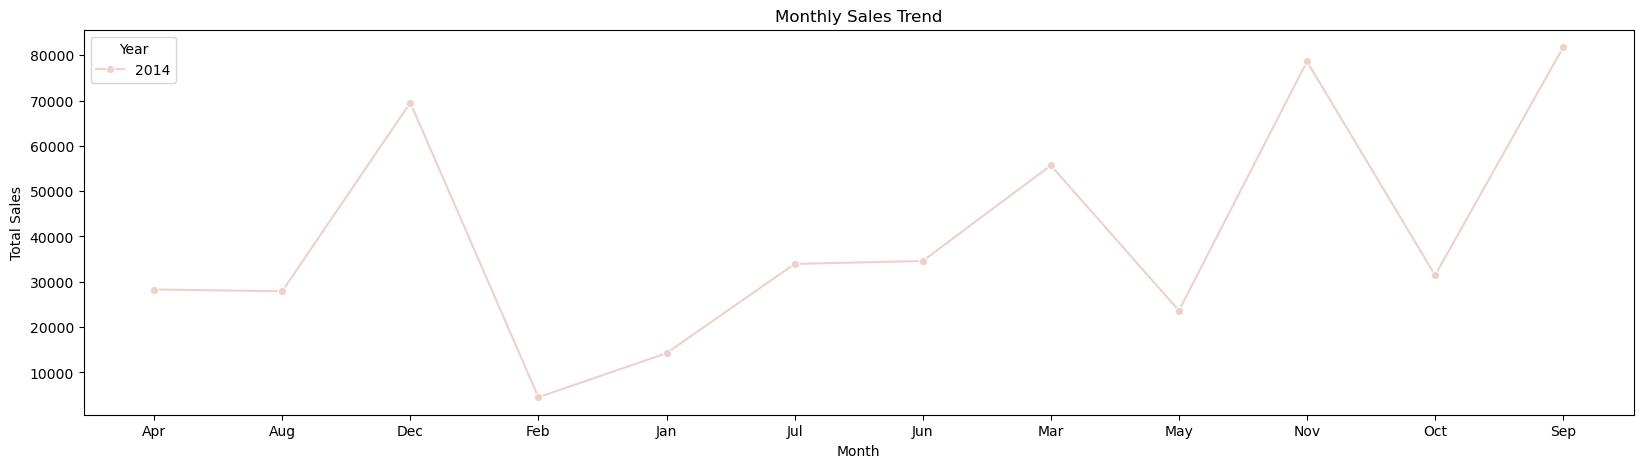

In [69]:
# Monthly Sales Trend Viz

monthly_revenue = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(20, 5))
sns.lineplot(x='Month', y='Sales', hue='Year', data=monthly_revenue, marker='o')

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.legend(title='Year')
plt.show()

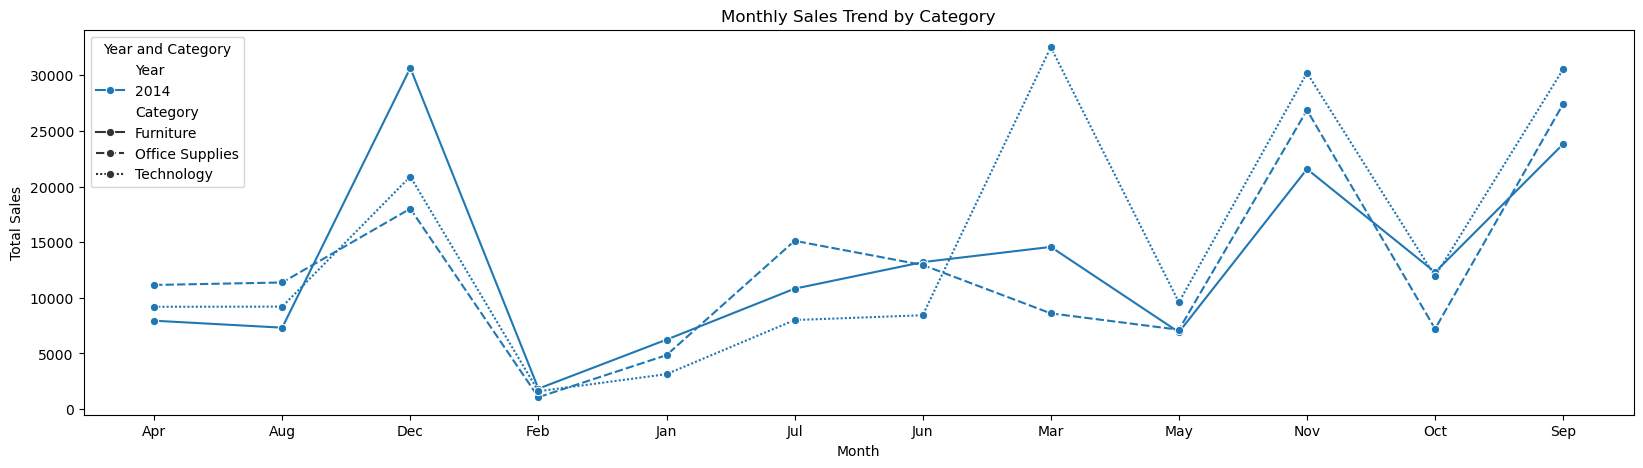

In [103]:
# Identifying sales spike in product category

monthly_revenue = df.groupby(['Year', 'Month', 'Category'])['Sales'].sum().reset_index()

plt.figure(figsize=(20, 5))
sns.lineplot(x='Month', y='Sales', hue='Year', style='Category', palette='tab10', data=monthly_revenue, marker='o')

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend by Category')
plt.legend(title='Year and Category', loc='best')
plt.show()
